<a href="https://colab.research.google.com/github/markajbell/BH/blob/main/stats_sec_50k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import time

# Record the start time
start_time = time.time()

# Setup & install packages and imports

In [2]:
!pip install pyvis
!pip install dot2tex

# Imports
import pandas as pd
import numpy as np
import json
import os
import glob
import re
import dot2tex
import pydot
import networkx as nx
import matplotlib.pyplot as plt

from networkx.drawing.nx_pydot import *
from pyvis.network import Network


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.5 MB/s eta 0:00:00


In [3]:
pd.set_option('display.max_rows', None)
pd.set_option("display.max_rows", None, "display.max_columns", None)
pd.set_option('display.max_colwidth', None)

# Download and process Files

In [4]:
!wget https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure50k.zip

if not os.path.exists('/content/adsync'):
    os.makedirs('/content/adsync')
    print("/content/adsync directory created.")
else:
    print("/content/adsync directory already exists.")

path = "/content/adsync"
!unzip -q secure50k.zip -d /content/adsync

data = {}
json_files = glob.glob(os.path.join(path, "*.json"))
for file in json_files:
    filename = os.path.basename(file).replace(".json", "")
    suf = filename.split("_")[-1]

    with open(file, 'r', encoding='utf-8') as f:
        content = json.load(f)

    if "data" in content:
        if suf in data:
            data[f"{suf}"].extend(content["data"])
        else:
            data[f"{suf}"] = content["data"]
    else:
        print(f"Warning: The key 'data' was not found in {f}.")

--2025-08-14 10:58:52--  https://raw.githubusercontent.com/markajbell/BH/refs/heads/main/adsync/secure50k.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3842228 (3.7M) [application/zip]
Saving to: ‘secure50k.zip’

secure50k.zip       100%[===================>]   3.66M  10.3MB/s    in 0.4s    

2025-08-14 10:58:53 (10.3 MB/s) - ‘secure50k.zip’ saved [3842228/3842228]

/content/adsync directory created.


# Create nodes and edges dataframe

In [5]:
df = pd.DataFrame(data[suf])
nodes = df[df['type'] == 'node'].copy()
edges = df[df['type'] == 'relationship'].copy()
nodes['id'] = nodes['id'].astype(int)

In [6]:
import pandas as pd
def extract_labels(labels):
    # Ensure labels is a list
    if not isinstance(labels, list):
        return [None, None, None]

    l1 = labels[0] if len(labels) > 0 else None
    l2 = labels[1] if len(labels) > 1 else None
    l3 = labels[2] if len(labels) > 2 else None
    return [l1, l2, l3]

# create the new columns
nodes[['l1', 'l2', 'l3']] = nodes['labels'].apply(lambda x: pd.Series(extract_labels(x)))

In [7]:
# Remove columns
nodes = nodes.drop(columns=['start', 'end', 'label', 'labels'])

In [8]:
edges.head()

,id,labels,properties,type,start,end,label
48286,r_0,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16297', 'labels': ['Base', 'OU']}",Contains
48287,r_1,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16298', 'labels': ['Base', 'OU']}",Contains
48288,r_2,NaN,{},relationship,"{'id': '16296', 'labels': ['Base', 'Domain']}","{'id': '16299', 'labels': ['Base', 'OU']}",Contains
48289,r_3,NaN,{},relationship,"{'id': '16297', 'labels': ['Base', 'OU']}","{'id': '16300', 'labels': ['Base', 'OU']}",Contains
48290,r_4,NaN,{},relationship,"{'id': '16297', 'labels': ['Base', 'OU']}","{'id': '16301', 'labels': ['Base', 'OU']}",Contains


# Get edge source and target, make int() & reset index

In [9]:
edges['source'] = edges['start'].apply(lambda x: x.get('id'))
edges['source_node'] = edges['start'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges['target'] = edges['end'].apply(lambda x: x.get('id'))
edges['target_node'] = edges['end'].apply(lambda x: x.get('labels')[1] if isinstance(x.get('labels'), list) and len(x.get('labels')) > 1 else None)

edges = edges.drop(columns=['properties', 'start', 'end', 'id', 'labels'])
edges['id'] = np.arange(len(edges)).astype('int64')
edges = edges.reset_index(drop=True)
nodes['weight'] = 1
edges = edges[['id', 'source', 'source_node', 'target', 'target_node', 'type','label']]
display(edges.head())
edges.info()

,id,source,source_node,target,target_node,type,label
0,0,16296,Domain,16297,OU,relationship,Contains
1,1,16296,Domain,16298,OU,relationship,Contains
2,2,16296,Domain,16299,OU,relationship,Contains
3,3,16297,OU,16300,OU,relationship,Contains
4,4,16297,OU,16301,OU,relationship,Contains


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235668 entries, 0 to 235667
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           235668 non-null  int64 
 1   source       235668 non-null  object
 2   source_node  235668 non-null  object
 3   target       235668 non-null  object
 4   target_node  235668 non-null  object
 5   type         235668 non-null  object
 6   label        235668 non-null  object
dtypes: int64(1), object(6)
memory usage: 12.6+ MB


In [10]:
#edges = edges.drop(columns=['id'])
nodes.info()
nodes.head()

<class 'pandas.core.frame.DataFrame'>
Index: 48286 entries, 0 to 48285
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          48286 non-null  int64 
 1   properties  48286 non-null  object
 2   type        48286 non-null  object
 3   l1          48286 non-null  object
 4   l2          48286 non-null  object
 5   l3          6 non-null      object
 6   weight      48286 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 2.9+ MB


,id,properties,type,l1,l2,l3,weight
0,16296,"{'domain': 'TESTLAB.LOCALE', 'name': 'TESTLAB.LOCALE', 'highvalue': True, 'objectid': 'S-1-5-21-883232822-274137685-4173207997', 'distinguishedname': 'DC=TESTLAB,DC=LOCALE', 'functionallevel': '2012', 'owned': False}",node,Base,Domain,None,1
1,16297,"{'domain': 'TESTLAB.LOCALE', 'name': 'Admin@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-fd56fdc5-0395-4f5d-9794-0f9ba2f24900', 'distinguishedname': 'OU=ADMIN,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
2,16298,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 1 Servers@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-64796a81-9520-42cd-811d-a110f76d1460', 'distinguishedname': 'OU=TIER 1 SERVERS,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
3,16299,"{'domain': 'TESTLAB.LOCALE', 'name': 'Tier 2@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-062e0ecf-5125-491b-ab8b-1f95e86cc312', 'distinguishedname': 'OU=TIER 2,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1
4,16300,"{'domain': 'TESTLAB.LOCALE', 'name': 'T0 Admin@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-49f45167-372a-41f4-b0d2-558328f4d614', 'distinguishedname': 'OU=T0 ADMIN,DC=TESTLAB,DC=LOCALE', 'description': None, 'highvalue': False, 'blocksInheritance': False, 'owned': False}",node,Base,OU,None,1


# Get last node['id'] & create super-node

In [11]:
lastnode=(len(str(nodes['id'].iloc[-1])))

new_node_id = int('9' * lastnode)

print(f"The new node ID is: {new_node_id}")

The new node ID is: 99999


In [12]:
# Create a dictionary with the new record's data
new_node_data = {
    'id': new_node_id,
    'properties': {'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-' + str(new_node_id), 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False},
    'type': 'node',
    'l1': 'ALL_T0',
    'l2': 'ALL_T0',
    'l3': 'ALL_T0',
    'weight': int(100)
}
# Convert the dictionary to a DataFrame
new_node_df = pd.DataFrame([new_node_data])

# Concatenate the new DataFrame with the existing nodes DataFrame
nodes = pd.concat([nodes, new_node_df], ignore_index=True)

In [13]:
nodes.tail()

,id,properties,type,l1,l2,l3,weight
48282,64578,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder498_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-49135', 'distinguishedname': 'CN=T2_HR_FOLDER498_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
48283,64579,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder499_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-49136', 'distinguishedname': 'CN=T2_HR_FOLDER499_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
48284,64580,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder500_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-49137', 'distinguishedname': 'CN=T2_HR_FOLDER500_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
48285,64581,"{'domain': 'TESTLAB.LOCALE', 'name': 'T2_HR_Folder501_Full@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-49138', 'distinguishedname': 'CN=T2_HR_FOLDER501_FULL,OU=T2 Security HR,OU=T2 Security Groups,OU=T2 Groups,OU=Tier 2,DC=TESTLAB,DC=LOCALE', 'description': 'This is a security group', 'highvalue': False, 'admincount': False, 'owned': False}",node,Base,Group,None,1
48286,99999,"{'domain': 'TESTLAB.LOCALE', 'name': 'ALL_T0@TESTLAB.LOCALE', 'objectid': 'S-1-5-21-883232822-274137685-4173207997-99999', 'distinguishedname': 'CN=ALL_T0,OU=ALL_T0,OU=ALL_T0,DC=TESTLAB,DC=LOCALE', 'description': 'All Tier 0 nodes', 'highvalue': True, 'admincount': True, 'owned': False}",node,ALL_T0,ALL_T0,ALL_T0,100


# create tier0_node_ids

In [14]:
tier0_node_ids = []

tier0_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: (
            any(
                term in x.get('distinguishedname', '')
                for term in ['TIER 0', 'Tier 0', 'T0', 'TIER0','CN=Enterprise Admins,', 'CN=Domain Admins,', 'CN=Administrator,']
            )
            or
            (
                re.search(r'.*-5[0-9]{2}$', x.get('objectid', '')) is not None and
                x.get('highvalue', False) == True and
                x.get('admincount', False) == True
            )
        )
    )
]['id'].tolist()

print(f"tier 0 (after checking filtered_nodes): {len(tier0_node_ids)}")

tier 0 (after checking filtered_nodes): 2669


# create tier1_node_ids and tier 2_node_ids

In [15]:
tier1_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 1', 'Tier 1', 'T1']
        )
    ) & (~nodes['id'].isin(tier0_node_ids))
]['id'].tolist()

tier2_node_ids = nodes[
    nodes['properties'].apply(
        lambda x: any(
            term in x.get('distinguishedname', '')
            for term in ['TIER 2', 'Tier 2', 'T2']

        )
    ) & (~nodes['id'].isin(tier0_node_ids))
]['id'].tolist()

print(f"tier 0 ",len(tier0_node_ids))
# tier1_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 1' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 1 ",len(tier1_node_ids))

# tier2_node_ids = nodes[nodes['properties'].apply(lambda x: 'Tier 2' in x.get('distinguishedname', ''))]['id'].tolist()
print(f"tier 2 ",len(tier2_node_ids))


tier 0  2669
tier 1  4970
tier 2  40783


# Set tier0,1,2 = 0 and then set from tier0,1,2:_node_ids..: ☣

In [16]:
#set Tier0, Tier1 and Tier2 to 0
nodes['Tier0'] = 0
nodes['Tier1'] = 0
nodes['Tier2'] = 0

# Set 'Tier0' to 1 if node id is in tier0_node_ids
nodes.loc[nodes['id'].isin(tier0_node_ids), 'Tier0'] = 1

# Set 'Tier1' to 1 if node id is in tier1_node_ids
nodes.loc[nodes['id'].isin(tier1_node_ids), 'Tier1'] = 1

# Set 'Tier2' to 1 if node id is in tier2_node_ids
nodes.loc[nodes['id'].isin(tier2_node_ids), 'Tier2'] = 1

# check counts are correct for nodes Tier0,1 & 2

In [17]:
tier0_count = nodes[nodes['Tier0'] == 1].shape[0]
tier1_count = nodes[nodes['Tier1'] == 1].shape[0]
tier2_count = nodes[nodes['Tier2'] == 1].shape[0]

print(f"Number of nodes in Tier 0: {tier0_count}")
print(f"Number of nodes in Tier 1: {tier1_count}")
print(f"Number of nodes in Tier 2: {tier2_count}")

Number of nodes in Tier 0: 2669
Number of nodes in Tier 1: 4970
Number of nodes in Tier 2: 40783


# set nodes weight, tier0=20, tier1=10, tier2=5

In [18]:
for value in tier0_node_ids:
    if value  == new_node_id:
        nodes.loc[nodes['id'] == value, 'weight'] = 100
    else:
        nodes.loc[nodes['id'] == value, 'weight'] = 20

for value in tier1_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 10

for value in tier2_node_ids:
    nodes.loc[nodes['id'] == value, 'weight'] = 5


# find max edges['id'], then create a new record for all tier0 nodes

In [19]:
# Get the maximum existing edge ID
max_edge_id = edges['id'].max()
max_edge_id
i=1
new_edges = []
for i, tier0_id in enumerate(tier0_node_ids):
    new_edge = {
        'type': 'relationship',  # Assuming type is always 'relationship' for edges
        'source': tier0_id,
        'source_node': 'TIER0',
        'target_node': 'TIER0',
        'target': new_node_id,
        'label': 'TIER0',
        'weight': 100,
        'id': max_edge_id + i + 1 # Assign a unique ID
    }
    new_edges.append(new_edge)

# Convert the list of new edges to a DataFrame
new_edges_df = pd.DataFrame(new_edges)

# Concatenate the new edges DataFrame with the existing edges DataFrame
edges = pd.concat([edges, new_edges_df], ignore_index=True)

# Apply the weights based on the 'label' column

In [20]:
def assign_weight(label):
    if label == "GenericAll":
        return 9
    elif label == "Owns":
        return 10
    elif label == "GenericWrite":
        return 2
    elif label == "AllExtendedRights":
        return 6
    elif label == "CanRDP":
        return 2
    elif label == "Contains":
        return 2
    elif label == "DCSync":
        return 8
    elif label == "WriteDacl":
        return 5
    elif label == "WriteOwner":
        return 7
    elif label == "AddKeyCredentialLink":
        return 6
    elif label == "AdminTo":
        return 8
    elif label == "MemberOf":
        return 2
    elif label == "CanPSRemote":
        return 2
    elif label == "ExecuteDCOM":
        return 2
    elif label == "GPLink":
        return 3
    elif label == "HasSession":
        return 9
    elif label == "ReadLAPSPassword":
        return 2
    elif label == "GetChanges":
        return 3
    elif label == "GetChangesAll":
        return 3
    elif label == "AddSelf":
        return 3
    elif label == "ForceChangePassword":
        return 3
    elif label == "AddMember":
        return 5
    elif label == "AllowedToDelegate":
        return 5
    elif label == "AllowedToAct":
        return 4
    elif label == "TIER0":
        return 100
    else:
        return 1

edges['weight'] = edges['label'].apply(assign_weight)

# make edges['id'], source, target and weight int()

In [21]:
edges['id'] = edges['id'].astype('int64')
edges['source'] = edges['source'].astype('int64')
edges['target'] = edges['target'].astype('int64')
edges['weight'] = edges['weight'].astype('int64')

# make tier0, tier1 & tier2 dataframes and make id column

In [22]:
tier0_node_ids = pd.DataFrame(tier0_node_ids)
tier2_node_ids = pd.DataFrame(tier2_node_ids)
tier1_node_ids = pd.DataFrame(tier1_node_ids)
tier1_node_ids = tier1_node_ids.rename(columns={0: 'id'})
tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})
tier2_node_ids = tier2_node_ids.rename(columns={0: 'id'})


# filter out unwanted edges & nodes

In [23]:
selected_edges_t0 = edges[edges['source'].isin(tier2_node_ids['id']) & (edges['target'].isin(tier0_node_ids['id'])) & (~edges['source'].isin(tier0_node_ids['id'])) & (~edges['target'].isin(tier2_node_ids['id']))]
print(len(selected_edges_t0))
selected_nodes = nodes[nodes['id'].isin(tier2_node_ids['id'])]
print(len(selected_nodes))

3257
40783


# Fins shortest paths using Dijkstra

In [24]:
import networkx as nx

G = nx.DiGraph()


for index, row in selected_nodes.iterrows():
    G.add_node(int(row['id']), weight=row['weight'])


for index, row in selected_edges_t0.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

shortest_paths = {}
for source in G.nodes():
    shortest_paths[source] = nx.single_source_dijkstra_path(G, source)

shortest_paths_filtered = {
    source: {
        target: path
        for target, path in paths.items()
        if source != target
    }
    for source, paths in shortest_paths.items()
}
len(shortest_paths_filtered)

41253

# Get weigh of paths from output of Dijkstra

In [25]:
def get_edge_weight(start_node, end_node):
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    if not edge.empty:
        return edge.iloc[0]['weight']


shortest_paths_list = []
for source, paths in shortest_paths_filtered.items():
    if paths:
        for target, path in paths.items():
            shortest_paths_list.append({
                'source': int(source),
                'target': int(target),
                'path': path,
                'weight': get_edge_weight(source, target)
            })

#add up all the weights for each path

In [26]:
import pandas as pd
shortest_paths_list = pd.DataFrame(shortest_paths_list)

def get_edge_weight(start_node, end_node):
    edge = edges[(edges['source'] == start_node) & (edges['target'] == end_node)]
    return edge.iloc[0]['weight']

shortest_paths_with_weight = []

for index, path_info in shortest_paths_list.iterrows():
    total_weight = 0
    path = path_info['path']
    source = path_info['source']
    target = path_info['target']


    if isinstance(path, list):
        for i in range(len(path) - 1):
            start_node = path[i]
            end_node = path[i + 1]
            edge_weight = get_edge_weight(start_node, end_node)
            total_weight += edge_weight
            shortest_paths_with_weight.append({'source': source, 'target': target, 'path': path, 'total_weight': total_weight})

df_shortest_paths_with_weight = pd.DataFrame(shortest_paths_with_weight).copy()

len(df_shortest_paths_with_weight)

3257

# display the sec1k$_{max}$ edges using networkx & matplotlib

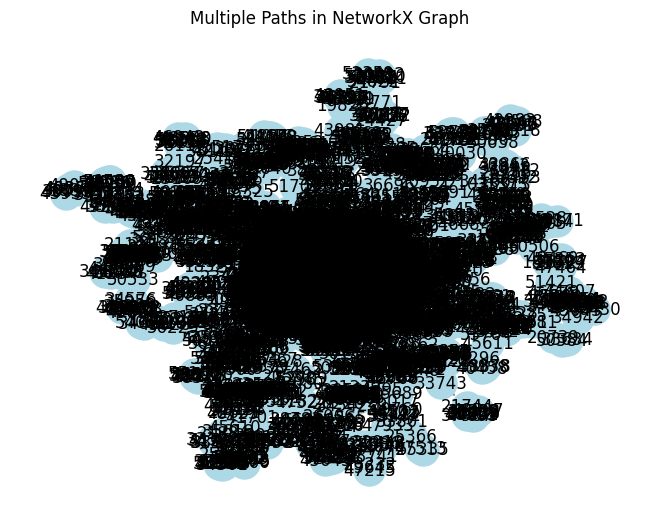

In [27]:
import networkx as nx
import matplotlib.pyplot as plt

df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]

paths = df_max['path']

G = nx.DiGraph()


for path in paths:

    edges_G = list(zip(path[:-1], path[1:]))
    G.add_edges_from(edges_G)


pos = nx.spring_layout(G, scale=2,k=0.85, iterations=50)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=500)

plt.title("Multiple Paths in NetworkX Graph")
plt.show()

# Create sec1k$_{max}$ fdp plot using pydot

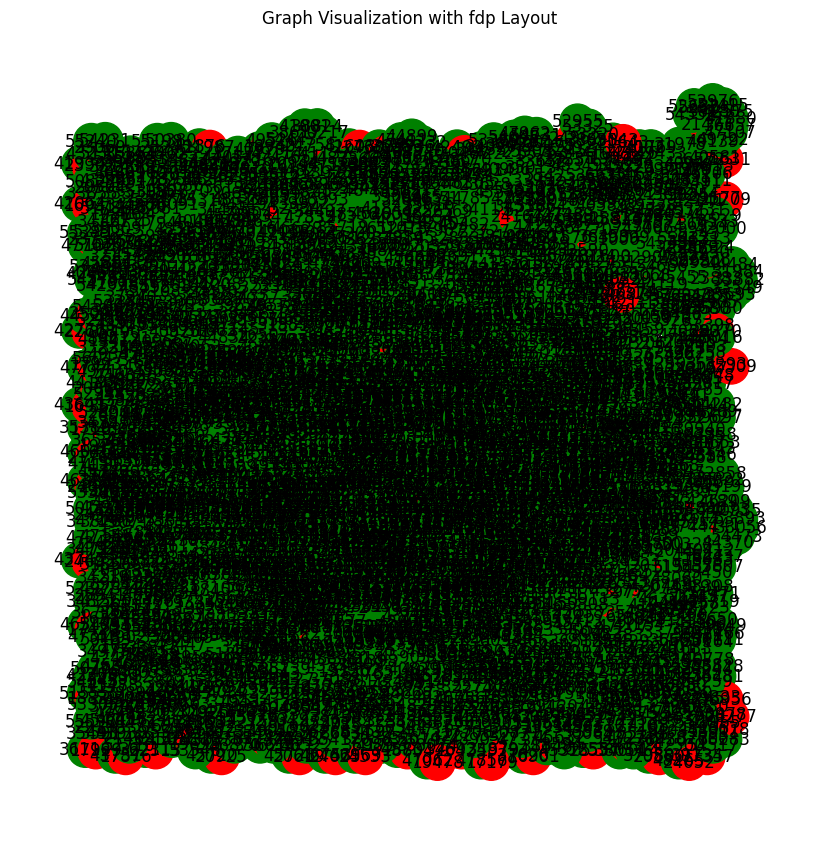

In [28]:
df=df_shortest_paths_with_weight


df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df[(df['total_weight'] == df_max_weight) & (df['source'].isin(tier2_node_ids['id'].values))]

# Convert node id lists to sets
tier0_ids_set = set(tier0_node_ids['id'].values)
tier1_ids_set = set(tier1_node_ids['id'].values)
tier2_ids_set = set(tier2_node_ids['id'].values)

G = nx.DiGraph()

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    for node in path:
        G.add_node(str(node))

    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []

for node in G.nodes():
    if int(node) in tier0_ids_set:
        colors.append('red')
        label ='Tier0'
        height=4
    elif int(node) in tier1_ids_set:
        colors.append('orange')
        height=2
    elif int(node) in tier2_ids_set:
        colors.append('green')
        height=1
    else:
        colors.append('yellow')

G.graph['ranksep'] = '.50'
G.graph['nodesep'] = '.50'

plt.figure(figsize=(8, 8))

 # Options depend on GraphViz version but may include: ‘dot’, ‘twopi’, ‘fdp’, ‘sfdp’, ‘circo’
pos = pydot_layout(G, prog="fdp", root=str(new_node_id))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with fdp Layout")
# save the plots
graph_name_max = suf + '_max_fdp_graph.pdf'
graph_name_max_png = suf + '_max_fdp_graph.png'
plt.savefig(graph_name_max, format="pdf")
plt.savefig(graph_name_max_png)
plt.show()
plt.close(graph_name_max_png)
plt.close(graph_name_max)
G_sav= G

In [29]:
print(nodes[nodes['id'] == 448])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


# Create sec1k$_{min}$ fdp plot

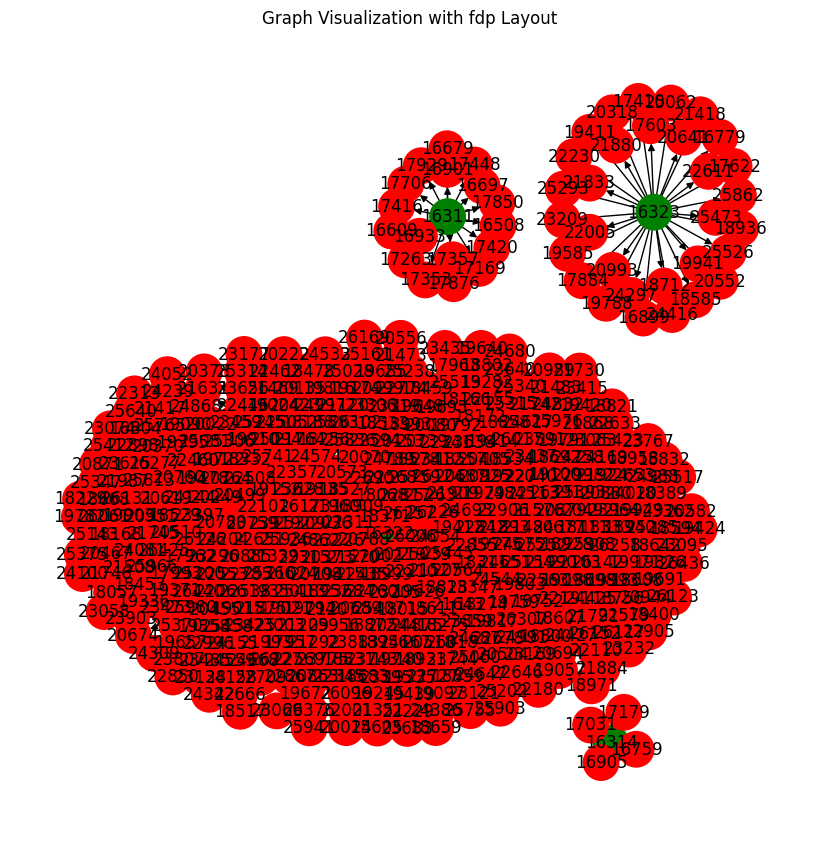

In [30]:
df=df_shortest_paths_with_weight

df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values))]

# Convert node id lists to sets
tier0_ids_set = set(tier0_node_ids['id'].values)
tier1_ids_set = set(tier1_node_ids['id'].values)
tier2_ids_set = set(tier2_node_ids['id'].values)

G = nx.DiGraph()


for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []

for node in G.nodes():
    if int(node) in tier0_ids_set:
        colors.append('red')
        label ='Tier0'
        height=4
    elif int(node) in tier1_ids_set:
        colors.append('orange')
        height=2
    elif int(node) in tier2_ids_set:
        colors.append('green')
        height=1
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
G.graph['ranksep'] = '.50'
G.graph['nodesep'] = '.50'

plt.figure(figsize=(8, 8))

# Options depend on GraphViz version but may include: ‘dot’, ‘twopi’, ‘fdp’, ‘sfdp’, ‘circo’
pos = pydot_layout(G, prog="fdp", root=str(new_node_id))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with fdp Layout")
# save the plots
graph_name_max_png = suf + '_min_fdp_graph.png'
graph_name_max = suf + '_min_fdp_graph.pdf'
plt.savefig(graph_name_max, format="pdf")
plt.savefig(graph_name_max_png)
plt.show()
plt.close(graph_name_max_png)
plt.close(graph_name_max)
G_sav_min= G

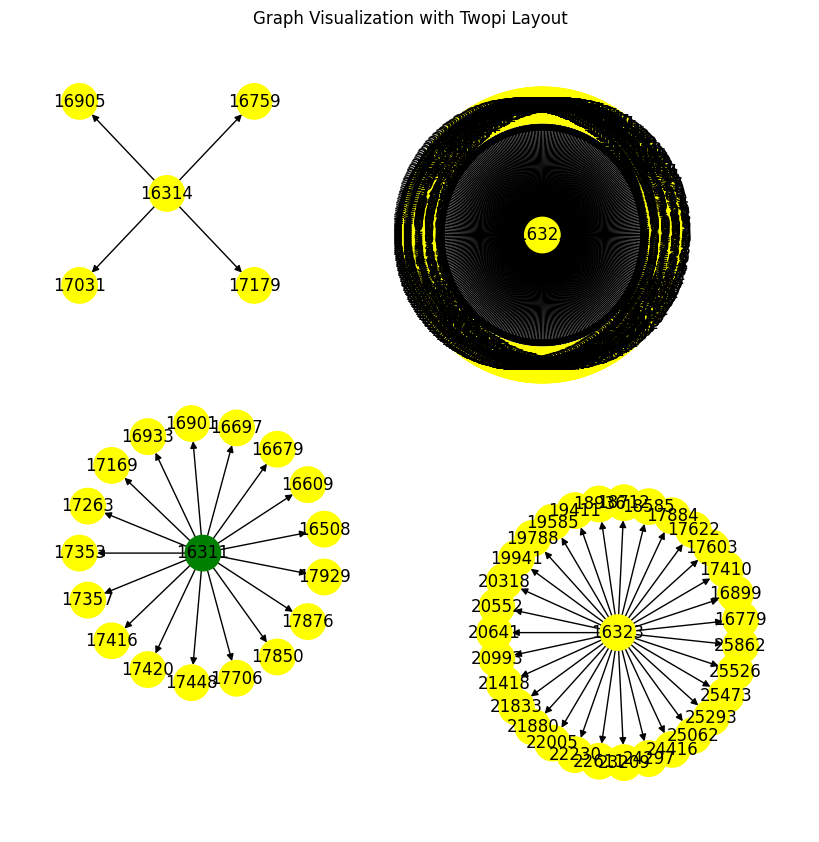

In [31]:
df=df_shortest_paths_with_weight

df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) ]

G = nx.DiGraph()

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    # Add nodes for all nodes in the path
    for node in path:
        G.add_node(str(node))

    # Add edges for consecutive nodes in the path
    for i in range(len(path) - 1):
        G.add_edge(str(path[i]), str(path[i+1]))
colors = []

for node in G.nodes():
    if (node) in str(tier0_node_ids['id'].values):
        colors.append('red')
        height=6
    elif (node) in (tier1_node_ids['id'].values):
        colors.append('orange')
        height=4
    elif (node) in str(tier2_node_ids['id'].values):
        colors.append('green')
        height=2
    else:
        colors.append('yellow')

# Set graph attributes to control spacing
G.graph['ranksep'] = '2.0'
G.graph['nodesep'] = '3.0'


plt.figure(figsize=(8, 8))

# Options depend on GraphViz version but may include: ‘dot’, ‘twopi’, ‘fdp’, ‘sfdp’, ‘circo’
pos = pydot_layout(G, prog="twopi", root=str(new_node_id))
nx.draw(G, pos, node_color=colors, with_labels=True, node_size=650, font_weight='normal')

plt.title("Graph Visualization with Twopi Layout")
graph_name = suf + '_min_twopi_graph.pdf'
graph_name_min_png = suf + '_min_twopi_graph.png'
plt.savefig(graph_name, format="pdf")
plt.savefig(graph_name_min_png)
plt.show()
plt.close(graph_name_min_png)
plt.close(graph_name)

# sec1k$_{min}$ graph.html using networkx.network

In [32]:
df=df_shortest_paths_with_weight


df_min_weight =0
df_min_weight = df_shortest_paths_with_weight['total_weight'].min()
df_min = df[(df['total_weight'] == df_min_weight) & (df['source'].isin(tier2_node_ids['id'].values)) &
            (df['target'].isin(tier0_node_ids['id'].values)) & (~df['source'].isin(tier0_node_ids['id'].values))]
p0 = df_min.shape[0]
#in_line, remote
net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True,
                select_menu=True
)

for index, row in df_min.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight'] # Changed 'total_weight' to 'weight'

    # Add nodes for all nodes in the path
    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red') # Changed color to red for Tier 0
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = " " + str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}") # Added weight and title to edge#suf="vul1k"
# neighbor_map = net.get_adj_list()

# # add neighbor data to node hover data
# for node in got_net.nodes:
#                 node["title"] += " Neighbors:<br>" + "<br>".join([str(neighbor) for neighbor in neighbor_map[node["id"]]])
#                 node["value"] = len(neighbor_map[node["id"]])
graph_name = suf + '_min_graph.html'

net.prep_notebook()
net.show_buttons(filter_=['nodes', 'edges', 'physics'])
net.show(graph_name)

secure50k_min_graph.html


# sec1k$_{max}$ graph.html using networkx.network

In [33]:
df_max_weight =0
df_max_weight = df_shortest_paths_with_weight['total_weight'].max()
df_max = df_shortest_paths_with_weight[df_shortest_paths_with_weight['total_weight'] == df_max_weight]

p1 = df_max.shape[0]

net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                directed=True
)
net.repulsion(node_distance=150, central_gravity=0.2, spring_length=200, spring_strength=0.05, damping=0.09)

for index, row in df_max.iterrows():
    source = row['source']
    target = row['target']
    path = row['path']
    weight = row['total_weight']

    for node in path:
      if node in tier0_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='red')
      elif node in tier1_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='orange')
      elif node in tier2_node_ids['id'].values:
        net.add_node(str(node), label=str(node), color='green')
      else:
        net.add_node(str(node), label=str(node), color='yellow')


    # Add edges for consecutive pairs of nodes in the path
    for i in range(len(path) - 1):
        lbl = str(path[i]) + "->" +str(path[i+1])
        net.add_edge(str(path[i]), str(path[i+1]), weight=weight, title=f"Weight: {weight},{lbl}")
graph_name = suf + '_max_graph.html'
net.prep_notebook()
net.show_buttons(filter_=['nodes', 'edges', 'physics'])
net.show(graph_name)

secure50k_max_graph.html


# Get nodes in path and create dataframe, export to $\LaTeX$ (V long)

In [34]:
# Create a list to store the data for the table
table_data = []

for index, row in df_max.iterrows():
    path = row['path']

    # Iterate through the nodes in the current path
    for node_id in path:
        # Find the node in the nodes DataFrame
        node_info = nodes[nodes['id'] == node_id]
        if not node_info.empty:
            properties = node_info.iloc[0]['properties']
            node_name = properties.get('name', 'N/A')
            is_tier0 = 1 if node_info.iloc[0]['Tier0'] == 1 else 0
            is_tier1 = 1 if node_info.iloc[0]['Tier1'] == 1 else 0
            is_tier2 = 1 if node_info.iloc[0]['Tier2'] == 1 else 0

            # Append the data as a dictionary to the list
            table_data.append({
                'Node Id': node_id,
                'Name': node_name,
                'Tier 0': is_tier0,
                'Tier 1': is_tier1,
                'Tier 2': is_tier2
            })

df_path_info = pd.DataFrame(table_data)
latex_table = df_path_info.to_latex(index=False)

file_name = suf + "_max_paths_table.tex"

with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"Table exported to {file_name}")

Table exported to secure50k_max_paths_table.tex


# gets stats, Count Computers, users, groups etc & save them to $\LaTeX$

In [35]:
from collections import Counter
#tier0_node_ids = tier0_node_ids.rename(columns={0: 'id'})

l0 = len(tier0_node_ids)
l1 = len(tier1_node_ids)
l2 = len(tier2_node_ids)
ln1 = len(nodes) -1
other  = ln1 - (l0 + l1 + l2)

amount_of_tier0_nodes = round(l0 / ln1 * 100,3)
print(f"% amount of tier0 nodes: {amount_of_tier0_nodes} %" )

amount_of_tier1_nodes = round(l1 /  ln1 * 100,3)
print(f"% amount of tier1 nodes: {amount_of_tier1_nodes} %" )

amount_of_tier2_nodes = round(l2 /  ln1 * 100,3)
print(f"% amount of tier2 nodes: {amount_of_tier2_nodes} %" )

amount_of_other_nodes = round(other /  ln1 * 100,3)
print(f"% amount of other nodes: {amount_of_other_nodes} %" )
tot = amount_of_tier2_nodes + amount_of_tier1_nodes + amount_of_tier0_nodes + amount_of_other_nodes
print(f"% amount of total nodes: {tot} %" )

l2_counts = Counter(nodes['l2'])

l2_counts_df = pd.DataFrame(l2_counts.items(), columns=['Value', 'Count'])
l2_counts_df = l2_counts_df.sort_values(by='Count')

latex_table = l2_counts_df.to_latex(index=False)

print(latex_table)


cnt_min_paths = round(p0 / ln1 * 100,3)
cnt_max_paths = round(p1 / ln1 * 100,3)

print(f"amount of min paths: {p0}: {cnt_min_paths} %" )
print(f"amount of max paths: {p1}: {cnt_max_paths} %" )
#name_count = len(connected)
# edges_len = len(edges['source'])
G_nodes_count_max = G_sav.number_of_nodes()
G_nodes_count_min = G_sav_min.number_of_nodes()
# print(f"Number of nodes in G_sav: {G_nodes_count}")
# prob = round(G_nodes_count / edges_len * 100,3)
# print(f"prob: {prob}%")
edges_len = len(edges['source'])
prob_min = round(G_nodes_count_min / edges_len * 100,3)
prob_max = round(G_nodes_count_max / edges_len * 100,3)
print(f"prob: {prob_min}%, {prob_max}%")

prob_data = {'count_max': [G_nodes_count_max], 'prob_max': [prob_max] , 'counts_min': [G_nodes_count_min], 'prob_min': [prob_min] , 'edges': [edges_len]}
prob_df = pd.DataFrame(prob_data)

file_name_prob = f"{suf}_probs.json"
prob_df.to_json(file_name_prob, orient='records', indent=4)

print(f"\nDataFrame saved to {file_name_prob}")

% amount of tier0 nodes: 5.527 %
% amount of tier1 nodes: 10.293 %
% amount of tier2 nodes: 84.461 %
% amount of other nodes: -0.282 %
% amount of total nodes: 99.999 %
\begin{tabular}{lr}
\toprule
Value & Count \\
\midrule
Domain & 1 \\
Container & 1 \\
ALL_T0 & 1 \\
GPO & 41 \\
OU & 48 \\
Group & 8181 \\
User & 15005 \\
Computer & 25009 \\
\bottomrule
\end{tabular}

amount of min paths: 468: 0.969 %
amount of max paths: 2789: 5.776 %
prob: 0.198%, 1.239%

DataFrame saved to secure50k_probs.json


In [36]:
l2_counts = nodes['l2'].value_counts().to_dict()
label_counts = edges['label'].value_counts().to_dict()


file_name_nodes = suf + "_nodes.json"
file_name_label = suf + "_label.json"

with open(file_name_nodes, 'w') as f:
    json.dump(l2_counts, f, indent=4)

with open(file_name_label, 'w') as f:
    json.dump(label_counts, f, indent=4)


# subgraph stats for sec1k $_{min}$ and $_{max}$

In [37]:
import json

edges_len = len(edges['source'])
print(f"edges_len: {edges_len}")
ratio = round(ln1/edges_len *100, 2)
print(f"ratio: {ratio}%")

ratio_subgraph_min = round(p0/edges_len *100, 2)
print(f"ratio_subgraph_min: {ratio_subgraph_min}%")

ratio_subgraph_max = round(p1/edges_len *100, 2)
print(f"ratio_subgraph_max: {ratio_subgraph_max}%")



# Create a dictionary with the requested format
output_data = {
    suf: {
        "values": {
            "Ratio": ratio,
            "ratio_min": ratio_subgraph_min,
            "ratio_max": ratio_subgraph_max
        }
    }
}

# Create the filename
file_name = suf + "_ratios.json"

# Save the dictionary as a JSON file
with open(file_name, 'w') as f:
    json.dump(output_data, f, indent=4)

print(f"Values exported to {file_name}")

edges_len: 238337
ratio: 20.26%
ratio_subgraph_min: 0.2%
ratio_subgraph_max: 1.17%
Values exported to secure50k_ratios.json


# find details from subgraph G$_s$ and save to $\LaTeX$

In [38]:
print(nodes[nodes['id'] == 444])

Empty DataFrame
Columns: [id, properties, type, l1, l2, l3, weight, Tier0, Tier1, Tier2]
Index: []


In [39]:
node_id = 448
connected_nodes = set()

# Iterate through the edges in graph G
for u, v in G_sav.edges():
    if u == str(node_id):
        connected_nodes.add(v)
    elif v == str(node_id):
        connected_nodes.add(u)

print(f"Nodes connected to {node_id}: {connected_nodes}")
connected = pd.DataFrame(list(connected_nodes), columns=['id'])
connected['id'] = connected['id'].astype(int)

names = []
# distinguished_names = []

for n_id in connected['id']:
    node_info = nodes[nodes['id'] == n_id]
    if not node_info.empty:
        node_properties = node_info.iloc[0]['properties']
        n_name = node_properties.get('name', 'N/A')
#        d_distinguishedname = node_properties.get('distinguishedname', 'Name not found')
        names.append(n_name)
#        distinguished_names.append(d_distinguishedname)
        # print(f"name for node {n_id} is: {n_name}, dn = {d_distinguishedname}" )
    else:
        names.append('Node not found')
#        distinguished_names.append('Node not found')
        # print(f"Node {n_id} not found in the nodes DataFrame.")

connected['name'] = names
# connected['d_distinguishedname'] = distinguished_names

#print(f"name_count: {name_count}")
display(connected)
json_name = suf + "_connected_nodes.json"
connected.to_json(json_name, indent=4)
# print out latex
latex_table = connected.to_latex(index=False)
print("\n\n2", latex_table)

file_name = "secure1k_connections.tex"
with open(file_name, 'w') as f:
    f.write(latex_table)

print(f"LaTeX table saved to {file_name}")



Nodes connected to 448: set()


,id,name




2 \begin{tabular}{rr}
\toprule
id & name \\
\midrule
\bottomrule
\end{tabular}

LaTeX table saved to secure1k_connections.tex


# End of Code

Degree Distribution for Maximum Weight Subgraph (G_sav):
Degree Counts: [0, 2357, 255, 39, 28, 26, 34, 26, 28, 45, 27, 33, 26, 28, 2]


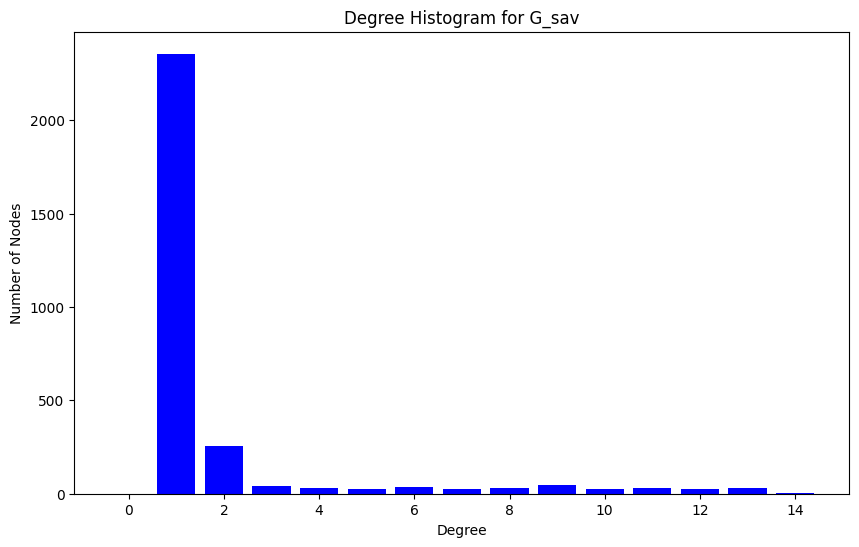


Betweenness Centrality for Maximum Weight Subgraph (G_sav):
Top 10 nodes by Betweenness Centrality: [('31446', 0.0), ('19420', 0.0), ('31449', 0.0), ('18933', 0.0), ('31453', 0.0), ('24425', 0.0), ('31462', 0.0), ('22036', 0.0), ('31487', 0.0), ('18068', 0.0)]

Eigenvector Centrality for Maximum Weight Subgraph (G_sav):
Top 10 nodes by Eigenvector Centrality: [('22036', 0.08842816009316573), ('22633', 0.08842816009316573), ('19420', 0.08211771678716595), ('21576', 0.08211771678716595), ('26173', 0.08211771678716595), ('26124', 0.08211771678716595), ('21893', 0.08211771678716595), ('20492', 0.08211771678716595), ('26131', 0.08211771678716595), ('20879', 0.08211771678716595)]

Degree Distribution for Complete Graph (G):
Degree Counts: [0, 468, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

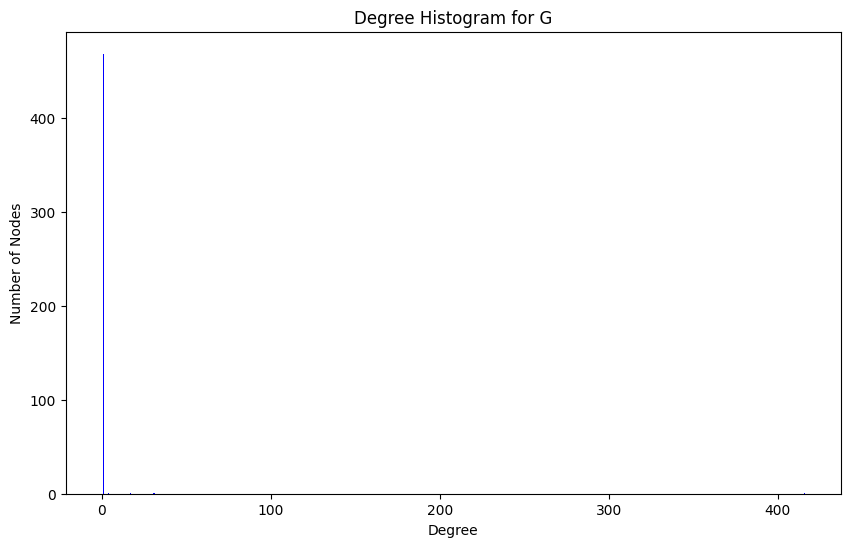


Betweenness Centrality for Complete Graph (G):
Top 10 nodes by Betweenness Centrality: [('16311', 0.0), ('16508', 0.0), ('16609', 0.0), ('16679', 0.0), ('16697', 0.0), ('16901', 0.0), ('16933', 0.0), ('17169', 0.0), ('17263', 0.0), ('17353', 0.0)]

Eigenvector Centrality for Complete Graph (G):
Top 10 nodes by Eigenvector Centrality: [('16508', 0.04622456841574519), ('16609', 0.04622456841574519), ('16679', 0.04622456841574519), ('16697', 0.04622456841574519), ('16901', 0.04622456841574519), ('16933', 0.04622456841574519), ('17169', 0.04622456841574519), ('17263', 0.04622456841574519), ('17353', 0.04622456841574519), ('17357', 0.04622456841574519)]


In [40]:
# Calculate Degree Distribution for G_sav (Maximum Weight Subgraph)
print("Degree Distribution for Maximum Weight Subgraph (G_sav):")
degree_sequence_sav = sorted([d for n, d in G_sav.degree()], reverse=True)
degree_count_sav = nx.degree_histogram(G_sav)
print("Degree Counts:", degree_count_sav)

# You can also visualize the degree distribution
plt.figure(figsize=(10, 6))
plt.bar(range(len(degree_count_sav)), degree_count_sav, width=0.80, color='b')
plt.title("Degree Histogram for G_sav")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.show()


# Calculate Betweenness Centrality for G_sav
print("\nBetweenness Centrality for Maximum Weight Subgraph (G_sav):")
betweenness_centrality_sav = nx.betweenness_centrality(G_sav)
# Display top 10 nodes by Betweenness Centrality
sorted_betweenness_sav = sorted(betweenness_centrality_sav.items(), key=lambda item: item[1], reverse=True)
print("Top 10 nodes by Betweenness Centrality:", sorted_betweenness_sav[:10])


# Calculate Eigenvector Centrality for G_sav
print("\nEigenvector Centrality for Maximum Weight Subgraph (G_sav):")
eigenvector_centrality_sav = nx.eigenvector_centrality(G_sav, max_iter=1000)
# Display top 10 nodes by Eigenvector Centrality
sorted_eigenvector_sav = sorted(eigenvector_centrality_sav.items(), key=lambda item: item[1], reverse=True)
print("Top 10 nodes by Eigenvector Centrality:", sorted_eigenvector_sav[:10])

# --- Now for the complete graph G ---

# Calculate Degree Distribution for the complete graph G (used for shortest paths)
# Note: The degree distribution for the complete graph might be less informative if it's very dense
print("\nDegree Distribution for Complete Graph (G):")
degree_sequence_g = sorted([d for n, d in G.degree()], reverse=True)
degree_count_g = nx.degree_histogram(G)
print("Degree Counts:", degree_count_g)

# You can also visualize the degree distribution
plt.figure(figsize=(10, 6))
plt.bar(range(len(degree_count_g)), degree_count_g, width=0.80, color='b')
plt.title("Degree Histogram for G")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.show()


# Calculate Betweenness Centrality for the complete graph G
print("\nBetweenness Centrality for Complete Graph (G):")
betweenness_centrality_g = nx.betweenness_centrality(G)
# Display top 10 nodes by Betweenness Centrality
sorted_betweenness_g = sorted(betweenness_centrality_g.items(), key=lambda item: item[1], reverse=True)
print("Top 10 nodes by Betweenness Centrality:", sorted_betweenness_g[:10])

# Calculate Eigenvector Centrality for the complete graph G
print("\nEigenvector Centrality for Complete Graph (G):")
eigenvector_centrality_g = nx.eigenvector_centrality(G, max_iter=1000)
# Display top 10 nodes by Eigenvector Centrality
sorted_eigenvector_g = sorted(eigenvector_centrality_g.items(), key=lambda item: item[1], reverse=True)
print("Top 10 nodes by Eigenvector Centrality:", sorted_eigenvector_g[:10])

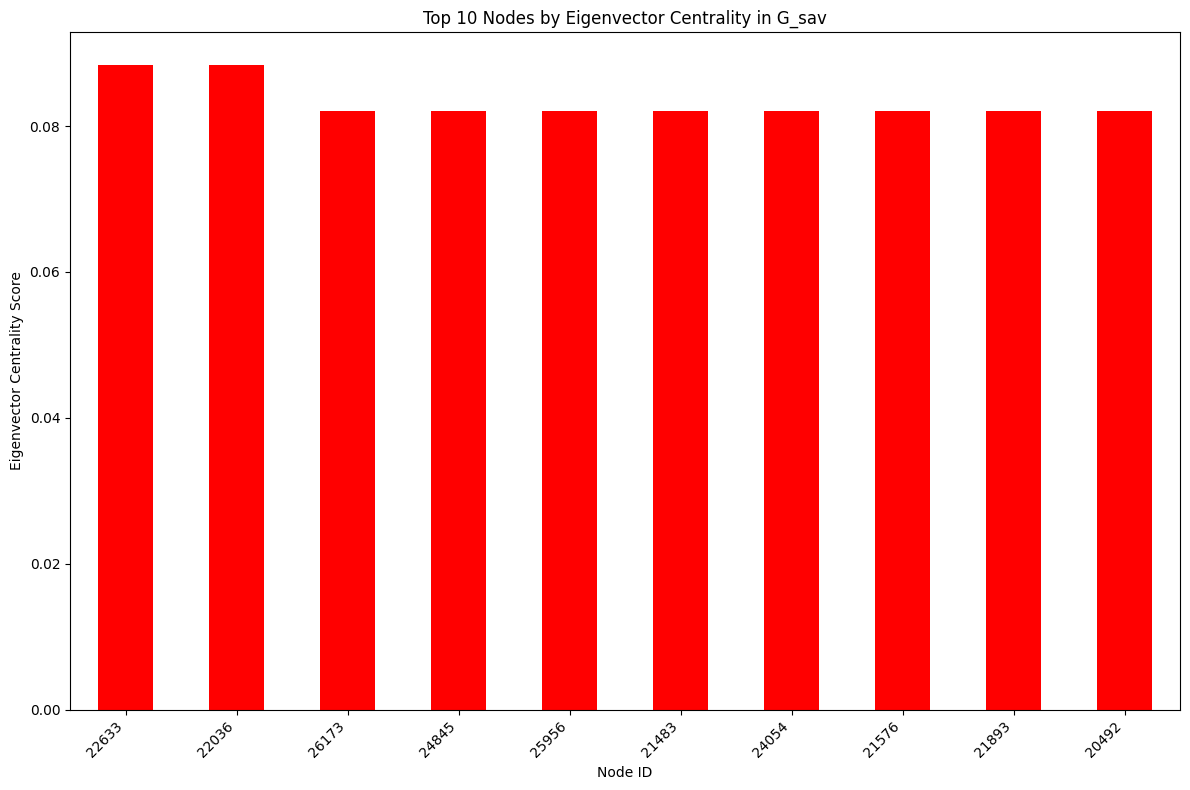

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

# Get the Eigenvector Centrality for G_sav (already calculated)
# eigenvector_centrality_sav = nx.eigenvector_centrality(G_sav, max_iter=1000) # Assuming this is already calculated and available

# Convert the dictionary to a pandas Series for easier sorting and plotting
eigenvector_series_sav = pd.Series(eigenvector_centrality_sav)

# Sort the nodes by Eigenvector Centrality in descending order
sorted_eigenvector_series_sav = eigenvector_series_sav.sort_values(ascending=False)

# Select the top N nodes to display (e.g., top 20)
top_n = 10
top_eigenvector_sav = sorted_eigenvector_series_sav.head(top_n)

# Create a bar plot
plt.figure(figsize=(12, 8))
top_eigenvector_sav.plot(kind='bar', color='red')
plt.title(f'Top {top_n} Nodes by Eigenvector Centrality in G_sav')
plt.xlabel('Node ID')
plt.ylabel('Eigenvector Centrality Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Save the plot as a PNG file
plt.savefig(f'{suf}_eigenvector_max.png')
plt.close() # Close the plot to free up memory

Eigenvector Centrality for Minimum Weight Subgraph (G_sav_min):
Top 10 nodes by Eigenvector Centrality: [('16508', 0.04622456841574519), ('16609', 0.04622456841574519), ('16679', 0.04622456841574519), ('16697', 0.04622456841574519), ('16901', 0.04622456841574519), ('16933', 0.04622456841574519), ('17169', 0.04622456841574519), ('17263', 0.04622456841574519), ('17353', 0.04622456841574519), ('17357', 0.04622456841574519)]


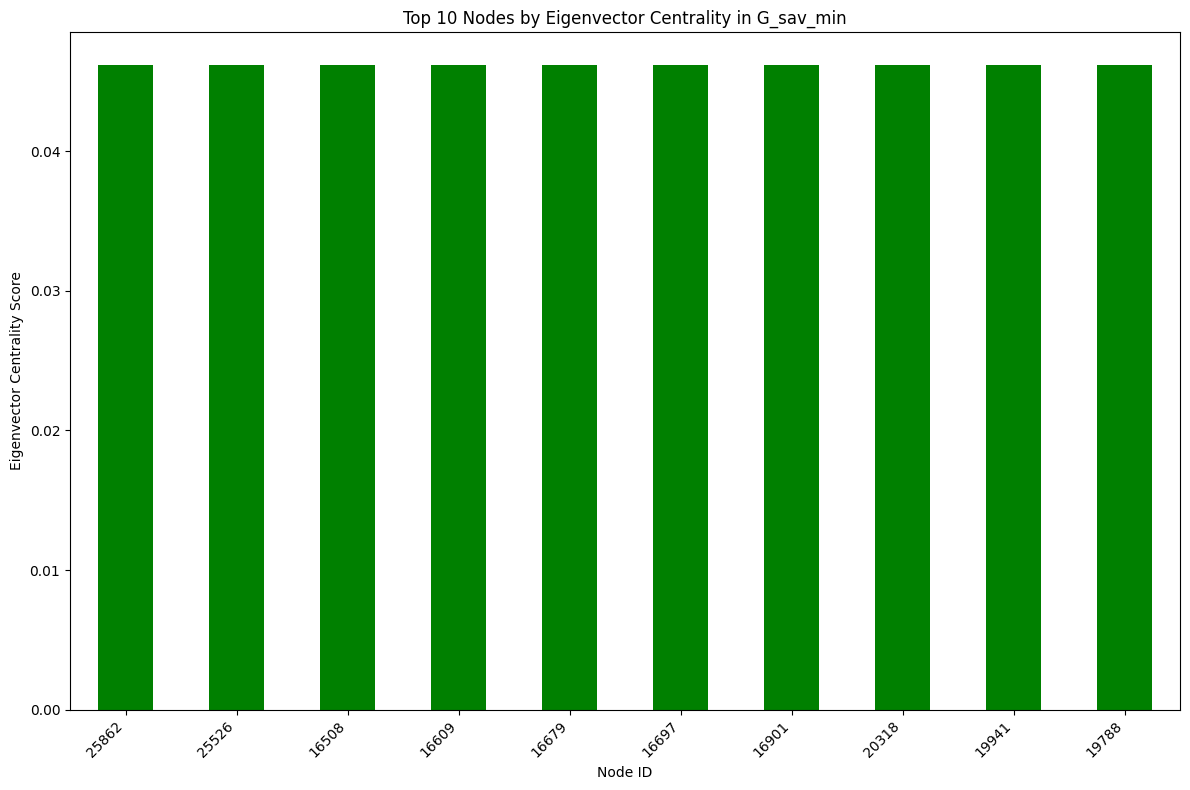

In [44]:
# Calculate Eigenvector Centrality for G_sav_min
print("Eigenvector Centrality for Minimum Weight Subgraph (G_sav_min):")
# Use max_iter=1000 for this calculation as well, based on previous experience
eigenvector_centrality_min = nx.eigenvector_centrality(G_sav_min, max_iter=1000)

# Display top 10 nodes by Eigenvector Centrality for G_sav_min
sorted_eigenvector_min = sorted(eigenvector_centrality_min.items(), key=lambda item: item[1], reverse=True)
print("Top 10 nodes by Eigenvector Centrality:", sorted_eigenvector_min[:10])

# Convert the dictionary to a pandas Series for easier sorting and plotting
eigenvector_series_min = pd.Series(eigenvector_centrality_min)

# Sort the nodes by Eigenvector Centrality in descending order
sorted_eigenvector_series_min = eigenvector_series_min.sort_values(ascending=False)

# Select the top N nodes to display (e.g., top 10 for visibility)
top_n_min = 10
top_eigenvector_min = sorted_eigenvector_series_min.head(top_n_min)

# Create a bar plot for the top nodes
plt.figure(figsize=(12, 8))
top_eigenvector_min.plot(kind='bar', color='green')
plt.title(f'Top {top_n_min} Nodes by Eigenvector Centrality in G_sav_min')
plt.xlabel('Node ID')
plt.ylabel('Eigenvector Centrality Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

# Save the plot as a PNG file
plt.savefig(f'{suf}_eigenvector_min.png')
plt.close() # Close the plot to free up memory

In [43]:
# Record the end time
end_time = time.time()

# Calculate the total execution time
total_time = end_time - start_time

print(f"Total execution time: {total_time:.2f} seconds")

Total execution time: 725.91 seconds
